In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df['Owner'].unique().tolist()

[0, 1, 3]

In [4]:
df['Transmission'].unique().tolist()

['Manual', 'Automatic']

In [5]:
df['Selling_type'].unique().tolist()

['Dealer', 'Individual']

In [6]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df.dtypes

,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Driven_kms,int64
Fuel_Type,object
Selling_type,object
Transmission,object
Owner,int64


In [9]:
print(df['Owner'].value_counts())

Owner
0    290
1     10
3      1
Name: count, dtype: int64


In [10]:
df.groupby('Owner')['Selling_Price'].mean()

,Selling_Price
Owner,
0,4.761552
1,1.970000
3,2.500000


In [11]:
df['Car_Name'].unique().tolist()

['ritz',
 'sx4',
 'ciaz',
 'wagon r',
 'swift',
 'vitara brezza',
 's cross',
 'alto 800',
 'ertiga',
 'dzire',
 'alto k10',
 'ignis',
 '800',
 'baleno',
 'omni',
 'fortuner',
 'innova',
 'corolla altis',
 'etios cross',
 'etios g',
 'etios liva',
 'corolla',
 'etios gd',
 'camry',
 'land cruiser',
 'Royal Enfield Thunder 500',
 'UM Renegade Mojave',
 'KTM RC200',
 'Bajaj Dominar 400',
 'Royal Enfield Classic 350',
 'KTM RC390',
 'Hyosung GT250R',
 'Royal Enfield Thunder 350',
 'KTM 390 Duke ',
 'Mahindra Mojo XT300',
 'Bajaj Pulsar RS200',
 'Royal Enfield Bullet 350',
 'Royal Enfield Classic 500',
 'Bajaj Avenger 220',
 'Bajaj Avenger 150',
 'Honda CB Hornet 160R',
 'Yamaha FZ S V 2.0',
 'Yamaha FZ 16',
 'TVS Apache RTR 160',
 'Bajaj Pulsar 150',
 'Honda CBR 150',
 'Hero Extreme',
 'Bajaj Avenger 220 dtsi',
 'Bajaj Avenger 150 street',
 'Yamaha FZ  v 2.0',
 'Bajaj Pulsar  NS 200',
 'Bajaj Pulsar 220 F',
 'TVS Apache RTR 180',
 'Hero Passion X pro',
 'Bajaj Pulsar NS 200',
 'Yamaha Faz

In [12]:
import numpy as np
from scipy import stats

col = df['Present_Price']

q1 = col.quantile(0.25)
q3 = col.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = col[(col < lower_bound) | (col > upper_bound)]

print(outliers)

50    30.61
51    30.61
53    30.61
59    35.96
62    35.96
63    35.96
64    36.23
66    23.15
79    30.61
82    25.39
85    23.73
86    92.60
93    30.61
96    25.39
Name: Present_Price, dtype: float64


In [13]:
df.loc[
    df['Present_Price'] > 20,
    ['Car_Name', 'Present_Price', 'Selling_Price']
]

,Car_Name,Present_Price,Selling_Price
50,fortuner,30.61,14.90
51,fortuner,30.61,23.00
53,fortuner,30.61,16.00
59,fortuner,35.96,19.99
62,fortuner,35.96,18.75
63,fortuner,35.96,23.50
64,fortuner,36.23,33.00
66,innova,23.15,19.75
67,fortuner,20.45,9.25
69,corolla altis,20.91,14.25


Although several observations were identified as statistical outliers using the IQR method, inspection revealed that they corresponded to high-value vehicles (e.g., fortuner). Since these values represent genuine market prices rather than data errors, they were retained for model training.

In [14]:
df['Car_Age'] = 2026 - df['Year']
df.drop('Year', axis=1, inplace=True)

In [15]:
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [16]:
print(df.columns)

Index(['Car_Name', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type',
       'Selling_type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='object')


In [17]:
df = pd.get_dummies(
    df,
    columns=['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission'],
    drop_first=True,
    dtype=int
)

print("\nOne-Hot Encoded Data:")
print(df.head())


One-Hot Encoded Data:
   Selling_Price  Present_Price  Driven_kms  Owner  Car_Age  \
0           3.35           5.59       27000      0       12   
1           4.75           9.54       43000      0       13   
2           7.25           9.85        6900      0        9   
3           2.85           4.15        5200      0       15   
4           4.60           6.87       42450      0       12   

   Car_Name_Activa 3g  Car_Name_Activa 4g  Car_Name_Bajaj  ct 100  \
0                   0                   0                       0   
1                   0                   0                       0   
2                   0                   0                       0   
3                   0                   0                       0   
4                   0                   0                       0   

   Car_Name_Bajaj Avenger 150  Car_Name_Bajaj Avenger 150 street  ...  \
0                           0                                  0  ...   
1                           0        

In [19]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age']

X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

Numerical features were standardized using StandardScaler to place them on a comparable scale before training the regression model

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [25]:
print(X.columns)

Index(['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Car_Name_Activa 3g',
       'Car_Name_Activa 4g', 'Car_Name_Bajaj  ct 100',
       'Car_Name_Bajaj Avenger 150', 'Car_Name_Bajaj Avenger 150 street',
       'Car_Name_Bajaj Avenger 220',
       ...
       'Car_Name_swift', 'Car_Name_sx4', 'Car_Name_verna',
       'Car_Name_vitara brezza', 'Car_Name_wagon r', 'Car_Name_xcent',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object', length=105)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 2.0365174789894307
RMSE: 3.036624835479502
R² Score: 0.5997023481939965


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R²:", r2_score(y_test, rf_pred))

Random Forest Results
MAE: 0.5978819672131149
RMSE: 0.8862315646768109
R²: 0.9659046469805138


Two regression models were trained to predict car selling prices: Linear Regression and Random Forest Regressor. The Random Forest model significantly outperformed Linear Regression, achieving an R² score of 0.966 compared to 0.600 for Linear Regression. Additionally, Random Forest produced substantially lower MAE and RMSE values, indicating more accurate predictions. This suggests that car prices exhibit complex, non-linear relationships with factors such as present price, age, mileage, ownership history, fuel type, and vehicle model. Therefore, Random Forest was selected as the preferred model for car price prediction.

In [30]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                     Feature  Importance
0              Present_Price    0.865438
3                    Car_Age    0.058639
1                 Driven_kms    0.031743
104      Transmission_Manual    0.009308
91     Car_Name_land cruiser    0.008078
84         Car_Name_fortuner    0.005850
101         Fuel_Type_Diesel    0.003628
89           Car_Name_innova    0.003410
72             Car_Name_city    0.003322
103  Selling_type_Individual    0.002980
74    Car_Name_corolla altis    0.002279
70            Car_Name_camry    0.001108
102         Fuel_Type_Petrol    0.000938
75            Car_Name_creta    0.000731
97            Car_Name_verna    0.000644


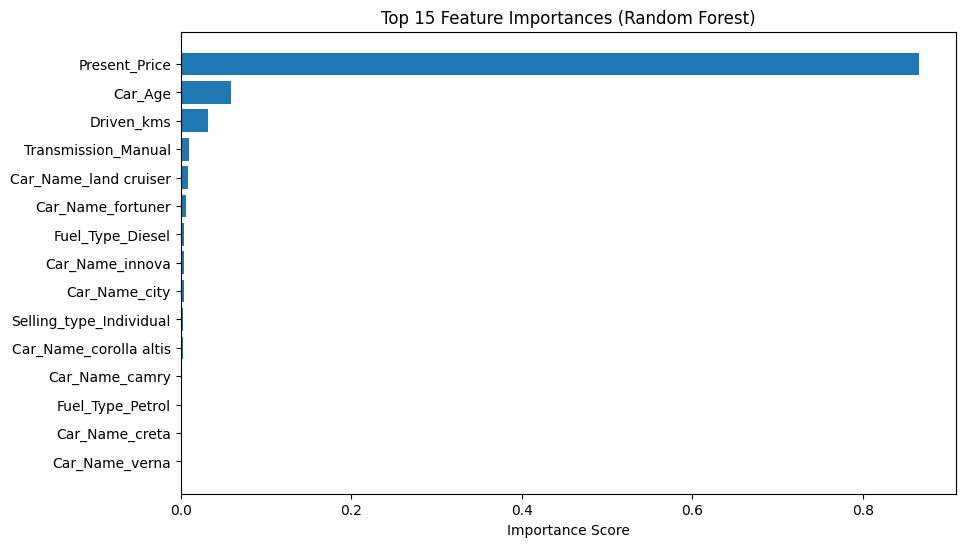

In [31]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

Hyperparameter Tuning (Random Forest)

In [32]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


Evaluate Best Model (Train-Test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned Random Forest Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Tuned Random Forest Results
MAE: 0.8954528119209271
RMSE: 1.5416636946602222
R²: 0.8968236753297953


K-Fold Cross Validation

In [37]:
from sklearn.model_selection import cross_val_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=None,
    random_state=42
)

cv_r2 = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("R² Mean:", cv_r2.mean())
print("R² Std:", cv_r2.std())

R² Mean: -6.428200055336158
R² Std: 14.378965470638244


In [38]:
print(cv_r2)

[  0.92263363   0.61744646 -35.18527574   0.83752556   0.66666981]


The model is sensitive to rare car categories and data distribution across folds, leading to instability in cross-validation performance.

Residual Analysis

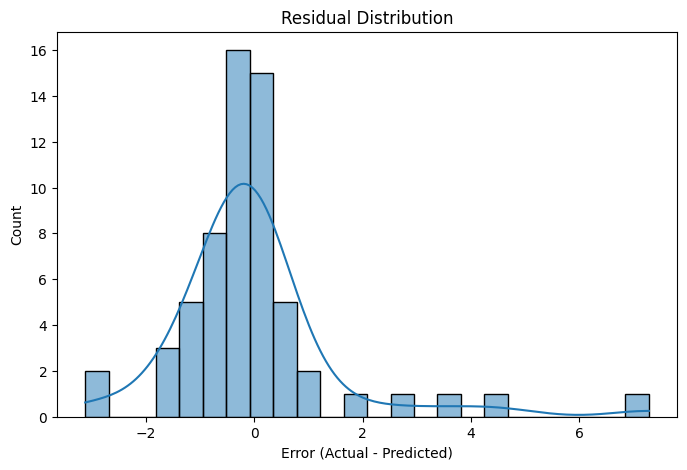

In [35]:
residuals = y_test - y_pred

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.show()

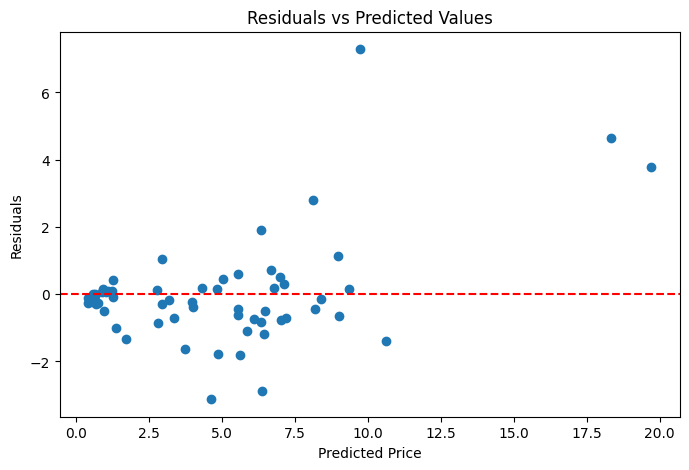

In [36]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()

1. Objective

The goal of this project was to develop a machine learning model to predict car selling prices based on features such as car age, present price, kilometers driven, ownership history, fuel type, transmission type, and car model.

2. Data Preprocessing

The dataset was cleaned and prepared for modeling through the following steps:

Verified that no missing values were present.
Created a new feature Car_Age from the manufacturing year.
Retained the Owner feature as it showed relevance to price variation.
Applied one-hot encoding to categorical variables including Car_Name, Fuel_Type, Selling_type, and Transmission.
Scaled numerical features using StandardScaler (for linear regression compatibility).


3. Model Building

Two regression models were trained:

Linear Regression
Random Forest Regressor

Random Forest was further optimized using RandomizedSearchCV, tuning parameters such as:

Number of estimators
Maximum depth
Minimum samples split and leaf size
Feature selection strategy


4. Model Performance
Baseline Linear Regression:
MAE: 2.03
RMSE: 3.03
R²: 0.60
Tuned Random Forest:
MAE: 0.89
RMSE: 1.54
R²: 0.89

Random Forest significantly outperformed Linear Regression, indicating that car price prediction is a non-linear problem.

5. Cross-Validation Results (K-Fold)

Cross-validation was performed using 5 folds with shuffled data:

R² scores across folds:

[0.92, 0.61, -35.18, 0.83, 0.66]
Interpretation:
Most folds showed strong predictive performance (0.6 to 0.92).
One fold produced a very low score (-35.18), indicating high sensitivity to data distribution.
This suggests the model is affected by dataset imbalance and rare car categories.
Overall Insight:

Despite variability, the model demonstrates strong performance on most data splits but shows instability due to limited dataset size and high-dimensional encoding of car names.

6. Feature Importance Insights

The most influential factors affecting car price were:

Present Price (most important)
Car Age
Kilometers Driven
Specific car models (Car_Name)
Fuel type and transmission (lower impact)

This confirms that market value and vehicle condition are the strongest predictors of resale price.

7. Residual Analysis (if included)

Residuals were randomly distributed around zero with no strong pattern, indicating that the model captures most of the underlying structure in the data. Slight variance at higher price ranges suggests mild heteroscedasticity.

8. Conclusion

The Random Forest Regressor is the most effective model for predicting car prices in this dataset. It captures complex non-linear relationships between features and significantly outperforms Linear Regression.

However, cross-validation results highlight some instability due to:

Small dataset size
High-dimensional one-hot encoded features
Rare car model categories